<a href="https://www.kaggle.com/code/lalit7881/pandemic-epidemic?scriptVersionId=304680950" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/strsheraz/historical-pandemic-epidemic/Historical_Pandemic_Epidemic_Dataset.csv


## Loading dataset

In [2]:
file_path = '/kaggle/input/datasets/strsheraz/historical-pandemic-epidemic/Historical_Pandemic_Epidemic_Dataset.csv'
df = pd.read_csv(file_path)


In [3]:
df.head()

,Event_Name,Pathogen_Name,Pathogen_Type,Start_Year,End_Year,Duration_Years,Origin_Region,Geographic_Spread,Continents_Affected,Estimated_Cases,...,Case_Fatality_Rate_Pct,Primary_Transmission,Containment_Method,Economic_Impact_Billion_USD,Medical_Breakthrough,Era,WHO_Classification,Mortality_Scale,Spread_Score,Century
0,Black Death,Yersinia pestis,Bacteria,1347,1353,6,Central Asia,Global,6,200000000,...,37.5,Vector/Contact,Natural Decline,500,True,Medieval,Pandemic,Catastrophic,22.50,14th Century
1,Plague of Justinian,Yersinia pestis,Bacteria,541,549,8,Egypt,Continental,4,50000000,...,50.0,Vector,Natural Decline,300,False,Ancient,Pandemic,Catastrophic,20.00,6th Century
2,Antonine Plague,Smallpox/Measles,Virus,165,180,15,Near East,Continental,3,10000000,...,50.0,Contact,Natural Decline,200,False,Ancient,Pandemic,High,15.00,2th Century
3,Second Pandemic Plague,Yersinia pestis,Bacteria,1361,1363,2,Europe,Continental,2,30000000,...,40.0,Vector,Natural Decline,100,False,Medieval,Pandemic,Catastrophic,8.00,14th Century
4,Sweating Sickness,Unknown,Unknown,1485,1551,66,England,Regional,1,300000,...,16.7,Unknown,Natural Decline,10,False,Medieval,Epidemic,Low,1.67,15th Century


In [4]:
df.tail()

,Event_Name,Pathogen_Name,Pathogen_Type,Start_Year,End_Year,Duration_Years,Origin_Region,Geographic_Spread,Continents_Affected,Estimated_Cases,...,Case_Fatality_Rate_Pct,Primary_Transmission,Containment_Method,Economic_Impact_Billion_USD,Medical_Breakthrough,Era,WHO_Classification,Mortality_Scale,Spread_Score,Century
45,Meningitis Belt Africa,Neisseria meningitidis,Bacteria,2009,2010,1,Africa,Regional,1,88199,...,6.07,Droplet,Vaccine,3,True,Contemporary,Epidemic,Low,0.607,21st Century
46,Anthrax Siberia,Bacillus anthracis,Bacteria,2016,2016,1,Russia,Local,1,2300,...,0.04,Contact,Antibiotics,1,False,Contemporary,Outbreak,Minimal,0.004,21st Century
47,Rocky Mountain Spotted Fever,Rickettsia rickettsii,Bacteria,1980,2023,43,USA,Regional,1,6000,...,1.00,Vector,Antibiotics,2,True,Modern,Endemic,Minimal,0.100,20th Century
48,Hantavirus,Hantavirus,Virus,1993,2023,30,USA,Regional,2,833,...,37.30,Contact,Supportive Care,2,True,Modern,Endemic,Minimal,7.460,20th Century
49,Q Fever Netherlands,Coxiella burnetii,Bacteria,2007,2010,3,Netherlands,Regional,1,4000,...,1.85,Airborne,Antibiotics,1,True,Contemporary,Epidemic,Minimal,0.185,21st Century


In [5]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Event_Name                   50 non-null     object 
 1   Pathogen_Name                50 non-null     object 
 2   Pathogen_Type                50 non-null     object 
 3   Start_Year                   50 non-null     int64  
 4   End_Year                     50 non-null     int64  
 5   Duration_Years               50 non-null     int64  
 6   Origin_Region                50 non-null     object 
 7   Geographic_Spread            50 non-null     object 
 8   Continents_Affected          50 non-null     int64  
 9   Estimated_Cases              50 non-null     int64  
 10  Estimated_Deaths             50 non-null     int64  
 11  Case_Fatality_Rate_Pct       50 non-null     float64
 12  Primary_Transmission         50 non-null     object 
 13  Containm

In [6]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
        Start_Year     End_Year  Duration_Years  Continents_Affected  \
count    50.000000    50.000000       50.000000            50.000000   
mean   1843.860000  1859.760000       15.960000             3.360000   
std     350.731714   350.103749       23.606433             2.301375   
min     165.000000   180.000000        1.000000             1.000000   
25%    1867.500000  1878.750000        1.000000             1.000000   
50%    1968.500000  2007.000000        5.500000             3.000000   
75%    2009.750000  2023.000000       16.500000             6.000000   
max    2022.000000  2023.000000      107.000000             7.000000   

       Estimated_Cases  Estimated_Deaths  Case_Fatality_Rate_Pct  \
count     5.000000e+01      5.000000e+01               50.000000   
mean      1.482741e+08      5.720644e+06               22.553240   
std       3.960562e+08      1.570972e+07               24.523933   
min       2.300000e+01      1.000000e+00                0

In [7]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Event_Name', 'Pathogen_Name', 'Pathogen_Type', 'Start_Year',
       'End_Year', 'Duration_Years', 'Origin_Region', 'Geographic_Spread',
       'Continents_Affected', 'Estimated_Cases', 'Estimated_Deaths',
       'Case_Fatality_Rate_Pct', 'Primary_Transmission', 'Containment_Method',
       'Economic_Impact_Billion_USD', 'Medical_Breakthrough', 'Era',
       'WHO_Classification', 'Mortality_Scale', 'Spread_Score', 'Century'],
      dtype='object')


In [8]:
print("\n=== Summary Statistics ===")
print(df.describe(include='all'))


=== Summary Statistics ===
         Event_Name    Pathogen_Name Pathogen_Type   Start_Year     End_Year  \
count            50               50            50    50.000000    50.000000   
unique           50               34             3          NaN          NaN   
top     Black Death  Vibrio cholerae         Virus          NaN          NaN   
freq              1                7            26          NaN          NaN   
mean            NaN              NaN           NaN  1843.860000  1859.760000   
std             NaN              NaN           NaN   350.731714   350.103749   
min             NaN              NaN           NaN   165.000000   180.000000   
25%             NaN              NaN           NaN  1867.500000  1878.750000   
50%             NaN              NaN           NaN  1968.500000  2007.000000   
75%             NaN              NaN           NaN  2009.750000  2023.000000   
max             NaN              NaN           NaN  2022.000000  2023.000000   

        Dur

In [9]:
df.isnull().sum()

Event_Name                     0
Pathogen_Name                  0
Pathogen_Type                  0
Start_Year                     0
End_Year                       0
Duration_Years                 0
Origin_Region                  0
Geographic_Spread              0
Continents_Affected            0
Estimated_Cases                0
Estimated_Deaths               0
Case_Fatality_Rate_Pct         0
Primary_Transmission           0
Containment_Method             1
Economic_Impact_Billion_USD    0
Medical_Breakthrough           0
Era                            0
WHO_Classification             0
Mortality_Scale                0
Spread_Score                   0
Century                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Event_Name                      object
Pathogen_Name                   object
Pathogen_Type                   object
Start_Year                       int64
End_Year                         int64
Duration_Years                   int64
Origin_Region                   object
Geographic_Spread               object
Continents_Affected              int64
Estimated_Cases                  int64
Estimated_Deaths                 int64
Case_Fatality_Rate_Pct         float64
Primary_Transmission            object
Containment_Method              object
Economic_Impact_Billion_USD      int64
Medical_Breakthrough              bool
Era                             object
WHO_Classification              object
Mortality_Scale                 object
Spread_Score                   float64
Century                         object
dtype: object

In [12]:
df.shape

(50, 21)

In [13]:
df.nunique()

Event_Name                     50
Pathogen_Name                  34
Pathogen_Type                   3
Start_Year                     44
End_Year                       32
Duration_Years                 25
Origin_Region                  29
Geographic_Spread               4
Continents_Affected             7
Estimated_Cases                45
Estimated_Deaths               43
Case_Fatality_Rate_Pct         40
Primary_Transmission           15
Containment_Method             13
Economic_Impact_Billion_USD    23
Medical_Breakthrough            2
Era                             6
WHO_Classification              4
Mortality_Scale                 5
Spread_Score                   44
Century                        10
dtype: int64

## EDA

In [14]:
sns.set(style="whitegrid")

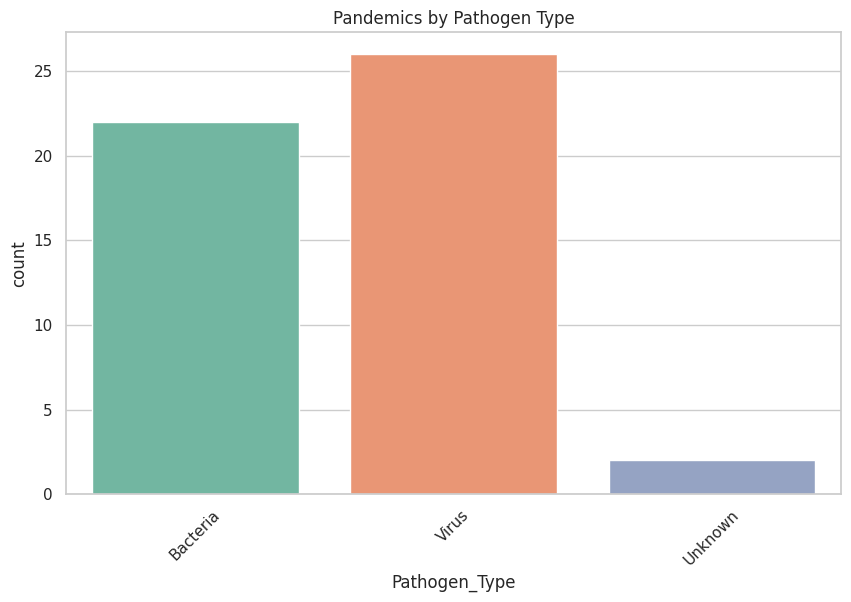

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pathogen_Type', palette='Set2')
plt.title('Pandemics by Pathogen Type')
plt.xticks(rotation=45)
plt.show()

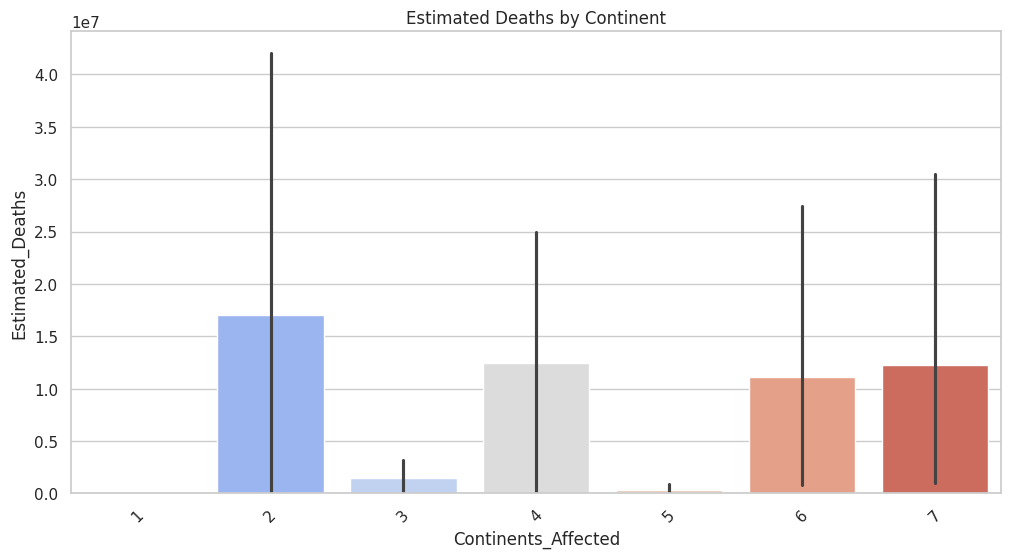

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Continents_Affected', y='Estimated_Deaths', palette='coolwarm')
plt.title('Estimated Deaths by Continent')
plt.xticks(rotation=45)
plt.show()

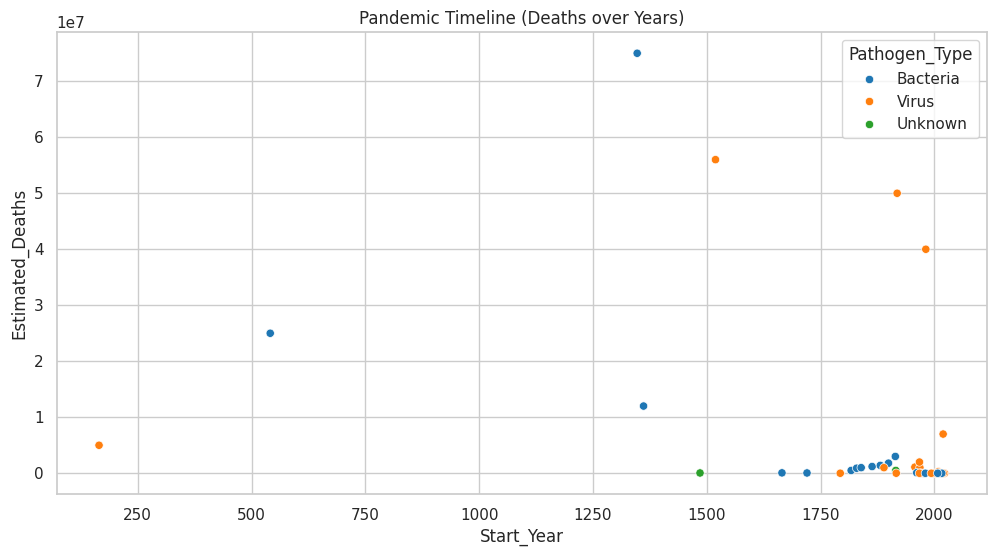

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Start_Year', y='Estimated_Deaths', hue='Pathogen_Type', palette='tab10')
plt.title('Pandemic Timeline (Deaths over Years)')
plt.show()

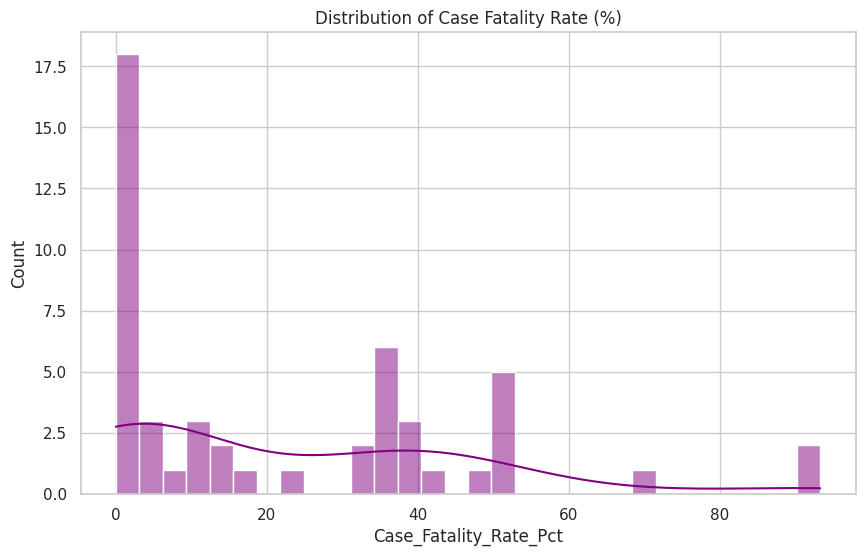

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['Case_Fatality_Rate_Pct'], bins=30, kde=True, color='purple')
plt.title('Distribution of Case Fatality Rate (%)')
plt.show()

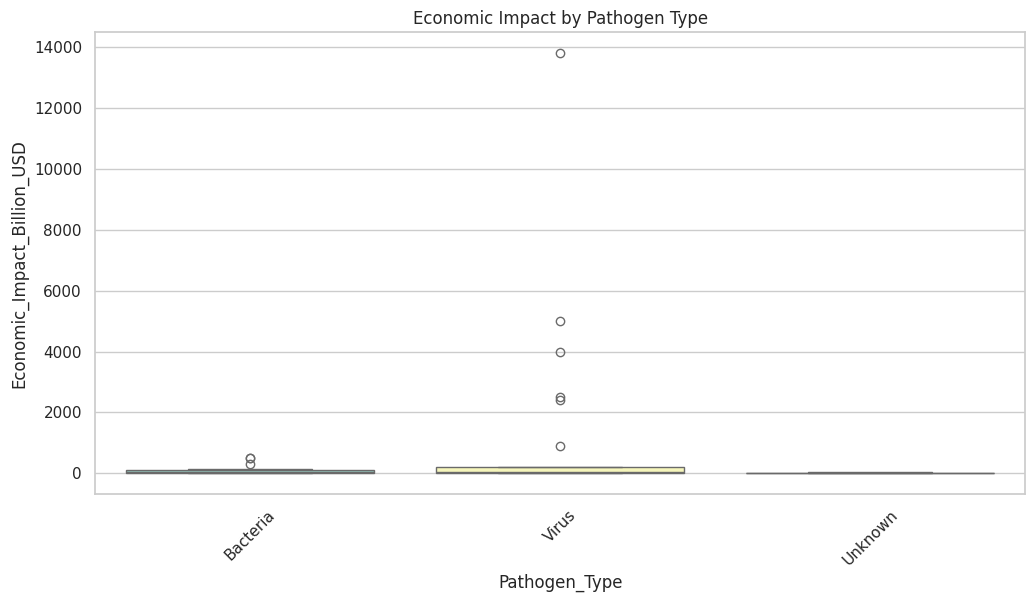

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Pathogen_Type', y='Economic_Impact_Billion_USD', palette='Set3')
plt.title('Economic Impact by Pathogen Type')
plt.xticks(rotation=45)
plt.show()

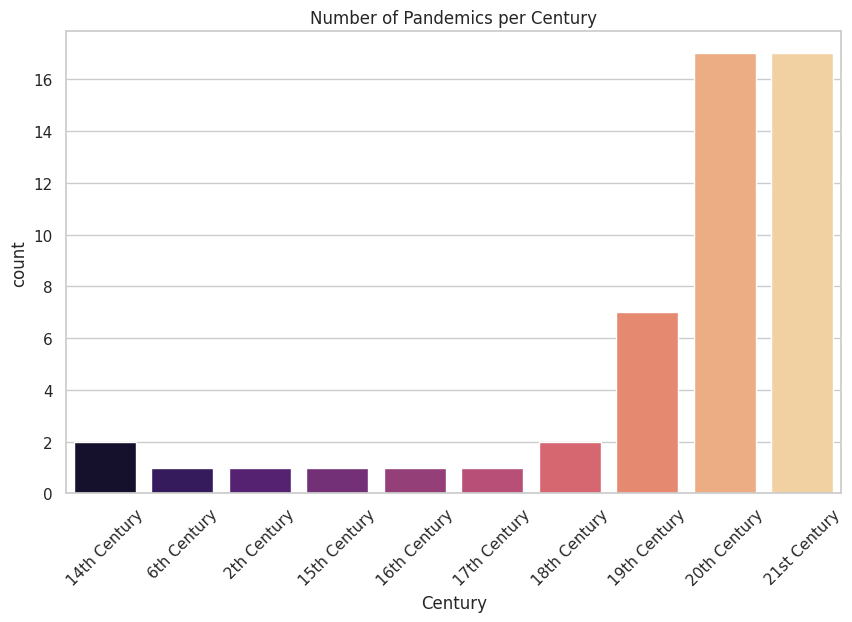

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Century', palette='magma')
plt.title('Number of Pandemics per Century')
plt.xticks(rotation=45)
plt.show()

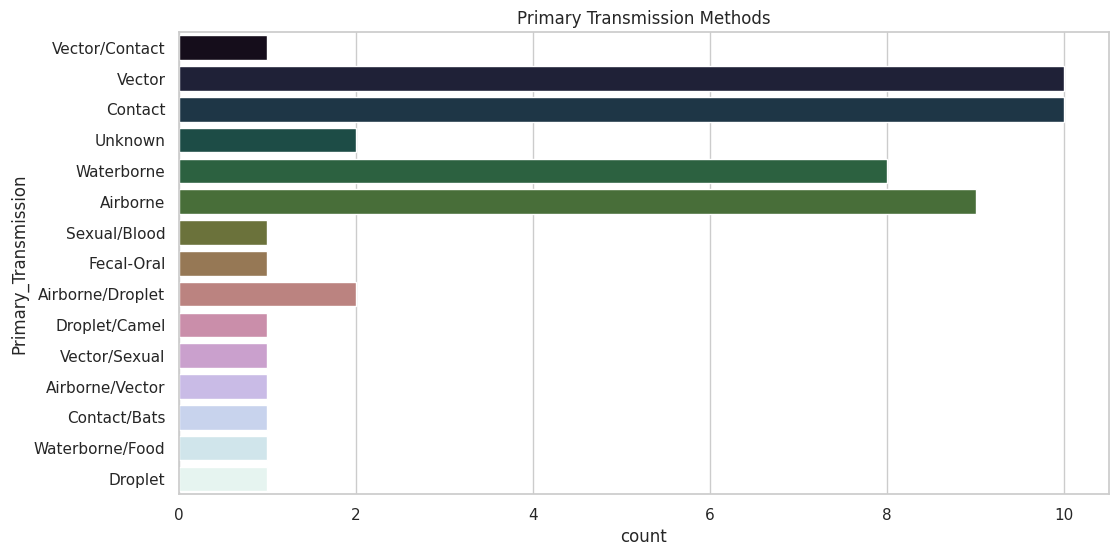

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Primary_Transmission', palette='cubehelix')
plt.title('Primary Transmission Methods')
plt.show()

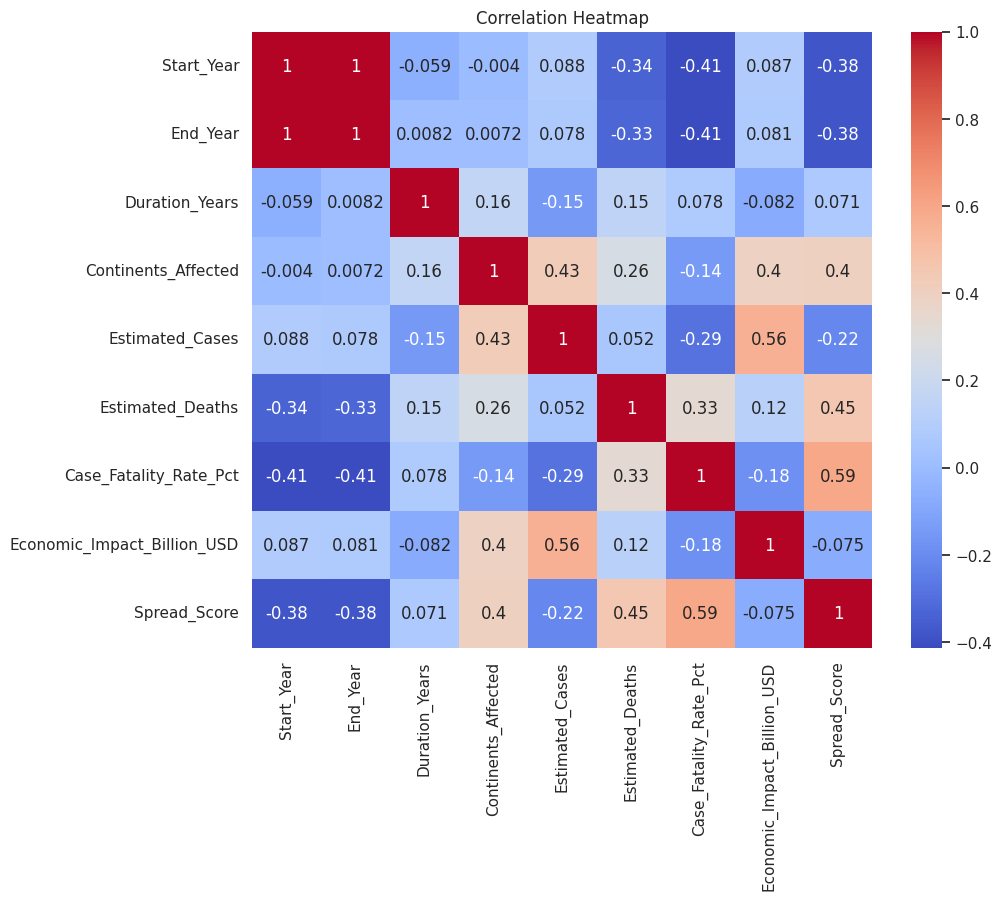

In [22]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

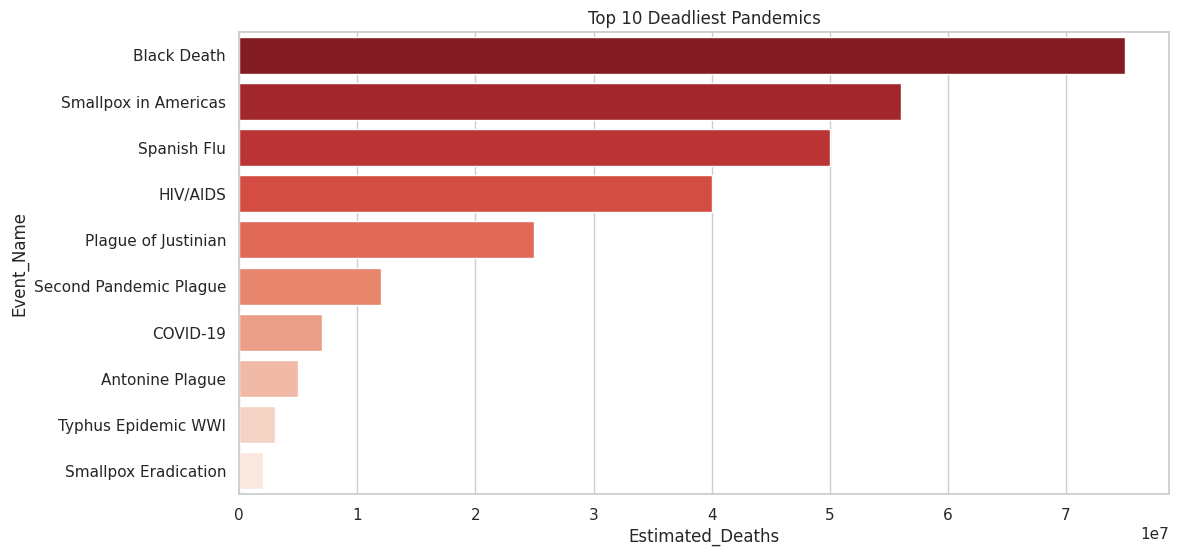

In [23]:
top_deadly = df.sort_values(by='Estimated_Deaths', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_deadly, x='Estimated_Deaths', y='Event_Name', palette='Reds_r')
plt.title('Top 10 Deadliest Pandemics')
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
df = df.drop(columns=['Event_Name', 'Pathogen_Name'], errors='ignore')

In [26]:
df = df.fillna(method='ffill')

In [27]:
target = 'Mortality_Scale'
X = df.drop(columns=[target])
y = df[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

In [30]:
cat_cols = X_train.select_dtypes(include='object').columns

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])


In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [33]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 20.00%
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.50      0.33      0.40         3
           4       0.00      0.00      0.00         2

    accuracy                           0.20        10
   macro avg       0.20      0.27      0.21        10
weighted avg       0.20      0.20      0.19        10


Decision Tree
Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weight

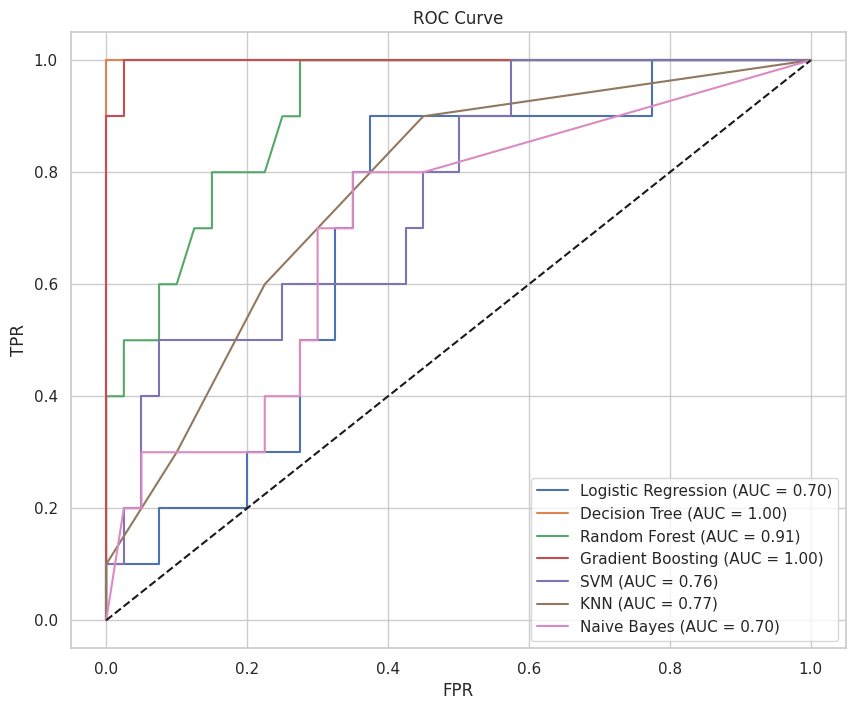

In [34]:
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10,8))

for name, model in models.items():
    try:
        y_prob = model.predict_proba(X_test)
        
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
        
    except:
        continue

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [35]:
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} ({results[best_model]*100:.2f}%)")


Best Model: Decision Tree (100.00%)


## Thank you..pls upvote!!!!!!!!!